In [5]:
import pandas as pd
import numpy as np
import re

files = [
    "/Users/mac/Desktop/DataVisualization/New_PM/Air Quality.xlsx",
    "/Users/mac/Desktop/DataVisualization/New_PM/Air Qauality 2025.xlsx"
]

station_map = {
    "TULKARM": "TULKARM",
    "QALQILYA": "QALQILYA",
    "NABLUS": "NAB00003",
    "ABU DIS": "JER00005",
    "JERUSALEM": "JER00005",
    "JERICHO": "JER00005",
    "RAMALLAH": "RAM00004",
    "PM10 QALQILYA": "QALQILYA"
}

def clean_pm_name(col):
    col = str(col).upper().replace(" ", "")
    if "DATE" in col:
        return "Date"
    if "AQI" in col:
        return "AQI"
    if "PM2.5" in col or "PM25" in col or "PM2.52" in col:
        return "PM2.5"
    if "PM10" in col:
        return "PM10"
    return col

def extract_pm_from_sheet(file_path, sheet_name):
    raw = pd.read_excel(file_path, sheet_name=sheet_name)

    blocks = []
    cols = list(raw.columns)

    # Find every Date column, then take the next columns as AQI/PM
    date_cols = [i for i, c in enumerate(cols) if "Date" in str(c)]

    for i in date_cols:
        block = raw.iloc[:, i:i+3].copy()
        block.columns = [clean_pm_name(c) for c in block.columns]

        if "Date" not in block.columns:
            continue

        # Keep only useful columns
        keep = [c for c in ["Date", "AQI", "PM2.5"] if c in block.columns]
        block = block[keep]

        block["Station"] = sheet_name.strip().upper()
        blocks.append(block)

    if len(blocks) == 0:
        return pd.DataFrame()

    out = pd.concat(blocks, ignore_index=True)

    out["Station"] = out["Station"].replace(station_map)
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce")

    for col in ["AQI", "PM2.5"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
            out.loc[out[col] < 0, col] = np.nan

    out = out.dropna(subset=["Date"])
    return out

# Read all files and sheets
all_pm = []

for file in files:
    xl = pd.ExcelFile(file)
    for sheet in xl.sheet_names:
        temp = extract_pm_from_sheet(file, sheet)
        if not temp.empty:
            all_pm.append(temp)

pm = pd.concat(all_pm, ignore_index=True)

print("PM columns:", pm.columns.tolist())
print(pm.head())

# Remove rows where all pollutant values are missing
pollutants = [c for c in ["AQI", "PM2.5"] if c in pm.columns]
pm = pm.dropna(subset=pollutants, how="all")

# Sort
pm = pm.sort_values(["Station", "Date"])

# Remove duplicates by averaging same Station-Date records
pm_clean = (
    pm.groupby(["Station", "Date"], as_index=False)
      .agg({
          "AQI": "mean",
          "PM2.5": "mean"
      })
)

# Interpolate only small gaps for PM2.5 / PM10 / AQI
for col in ["AQI", "PM2.5"]:
    if col in pm_clean.columns:
        pm_clean[col] = pm_clean.groupby("Station")[col].transform(
            lambda x: x.interpolate(method="linear", limit=2, limit_direction="both")
        )

# Add time features
pm_clean["Year"] = pm_clean["Date"].dt.year
pm_clean["Month"] = pm_clean["Date"].dt.month
pm_clean["Day"] = pm_clean["Date"].dt.day
pm_clean["DayOfWeek"] = pm_clean["Date"].dt.dayofweek

# Save
pm_clean.to_excel("pm_cleaned_final.xlsx", index=False)
pm_clean.to_csv("pm_cleaned_final.csv", index=False)

print("Saved: pm_cleaned_final.xlsx and pm_cleaned_final.csv")
print(pm_clean.info())
print(pm_clean.isna().sum())
print(pm_clean.groupby("Station")["Date"].agg(["min", "max", "count"]))

PM columns: ['Date', 'AQI', 'PM2.5', 'Station']
        Date   AQI  PM2.5  Station
0 2024-02-06  56.0   14.5  TULKARM
1 2024-02-07  55.0   14.2  TULKARM
2 2024-02-08  80.0   26.1  TULKARM
3 2024-02-09  69.0   20.7  TULKARM
4 2024-02-10  46.0   11.1  TULKARM
Saved: pm_cleaned_final.xlsx and pm_cleaned_final.csv
<class 'pandas.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Station    1518 non-null   str           
 1   Date       1518 non-null   datetime64[us]
 2   AQI        1518 non-null   float64       
 3   PM2.5      1518 non-null   float64       
 4   Year       1518 non-null   int32         
 5   Month      1518 non-null   int32         
 6   Day        1518 non-null   int32         
 7   DayOfWeek  1518 non-null   int32         
dtypes: datetime64[us](1), float64(2), int32(4), str(1)
memory usage: 71.3 KB
None
Station      0
Date         0
AQI       

In [6]:
weather = pd.read_excel("/Users/mac/Desktop/DataVisualization/New_PM/merged_weather_cleaned_final.xlsx")
pm = pd.read_excel("/Users/mac/Desktop/DataVisualization/New_PM/pm_cleaned_final.xlsx")

weather["Date"] = pd.to_datetime(weather["Date"])
pm["Date"] = pd.to_datetime(pm["Date"])

final_df = pd.merge(
    weather,
    pm[["Station", "Date", "AQI", "PM2.5"]],
    on=["Station", "Date"],
    how="inner"
)

final_df.to_excel("weather_pm_merged_final.xlsx", index=False)
final_df.to_csv("weather_pm_merged_final.csv", index=False)

print(final_df.info())
print(final_df.isna().sum())
print(final_df.groupby("Station")["Date"].agg(["min", "max", "count"]))

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Station      366 non-null    str           
 1   Date         366 non-null    datetime64[us]
 2   Temperature  366 non-null    float64       
 3   Sunshine     366 non-null    float64       
 4   RH           366 non-null    float64       
 5   PRESS        366 non-null    float64       
 6   Rainfall     366 non-null    float64       
 7   Wind         366 non-null    float64       
 8   Month        366 non-null    int64         
 9   Year         366 non-null    int64         
 10  Day          366 non-null    int64         
 11  DayOfWeek    366 non-null    int64         
 12  AQI          366 non-null    int64         
 13  PM2.5        366 non-null    float64       
dtypes: datetime64[us](1), float64(7), int64(5), str(1)
memory usage: 40.2 KB
None
Station        0
Date           0
Tempe

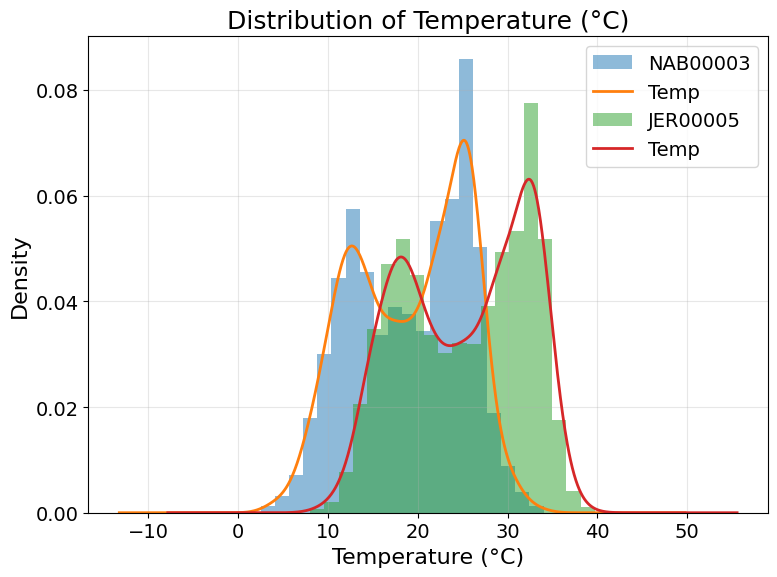

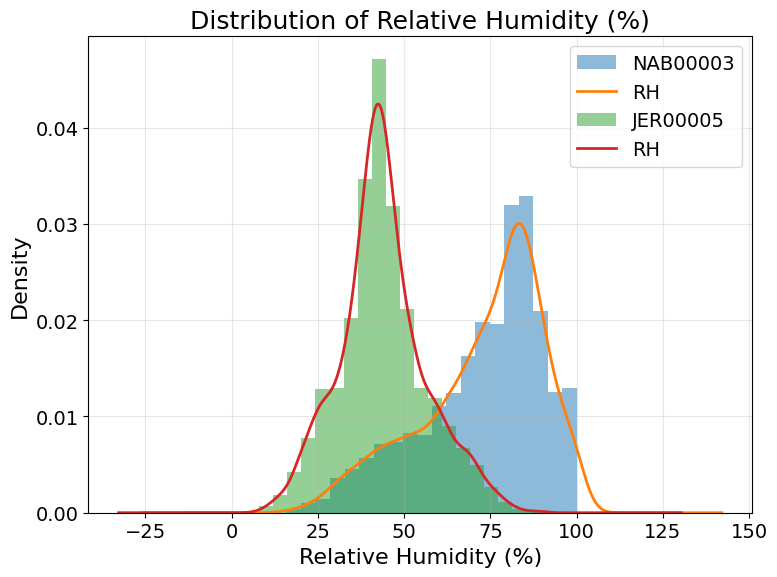

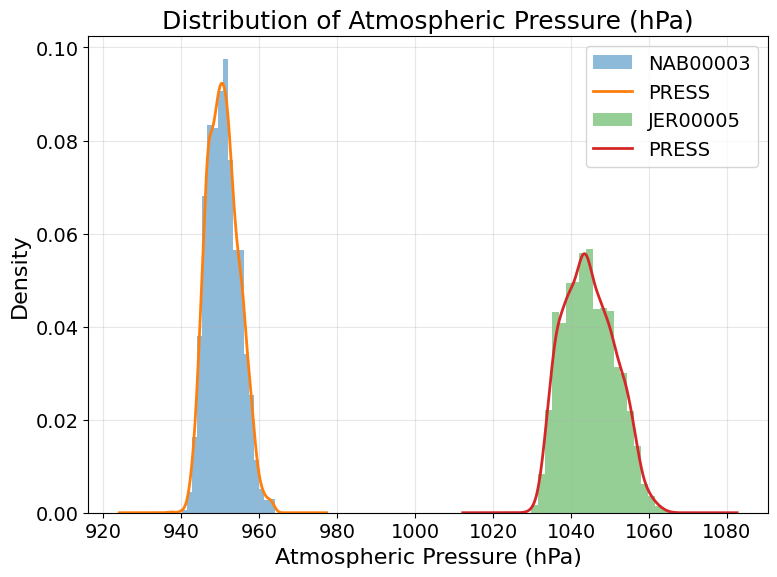

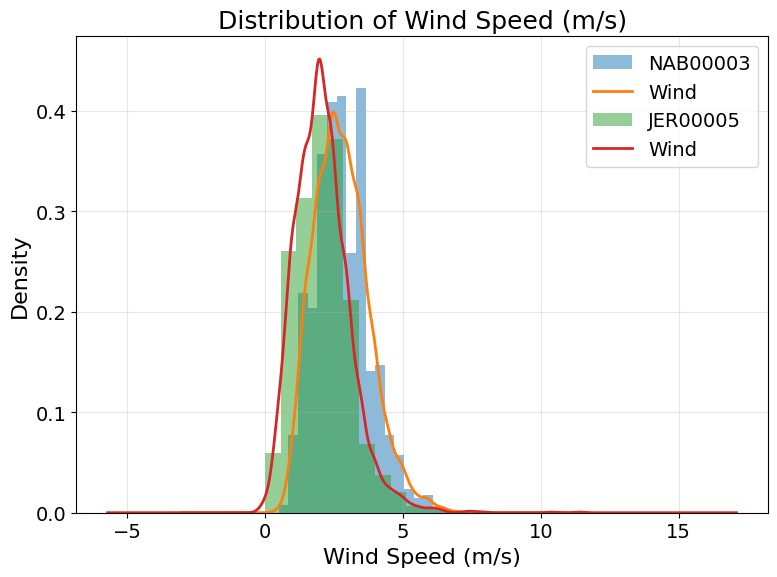

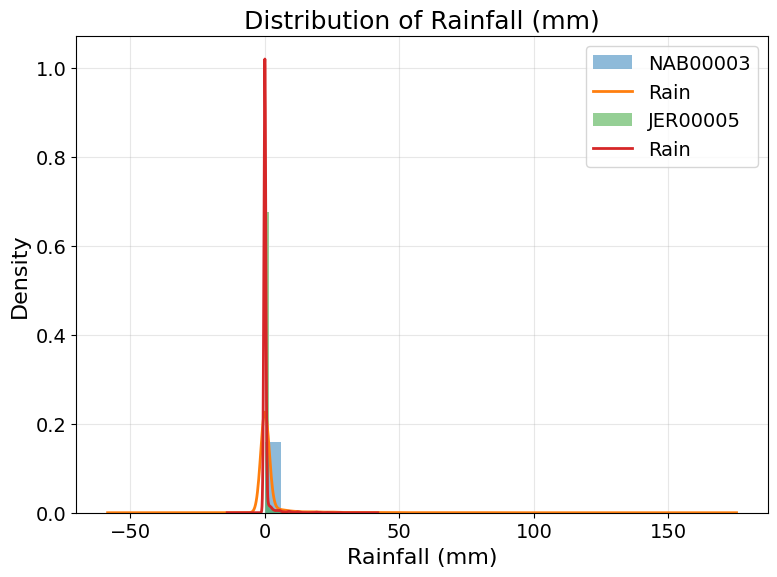

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

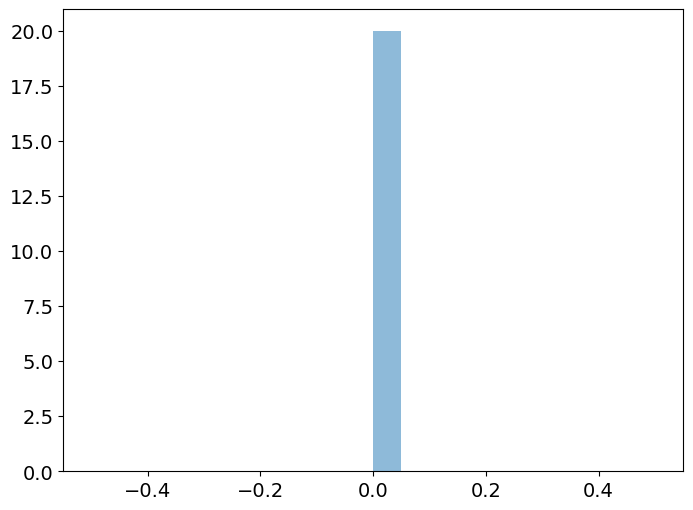

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ===========================
# Load dataset
# ===========================
df = pd.read_excel("/Users/mac/Desktop/enve/final enve/final_filled_climate.xlsx")   # Change path if needed

# ===========================
# Select stations
# ===========================
stations = ["NAB00003", "JER00005"]     # Change if your station names differ
df = df[df["Station"].isin(stations)]

# ===========================
# Variables to plot
# ===========================
variables = [
    "Temp",
    "RH",
    "PRESS",
    "Wind",
    "Rain",
    "SUNSHINE"
]

titles = {
    "Temp":"Temperature (°C)",
    "RH":"Relative Humidity (%)",
    "PRESS":"Atmospheric Pressure (hPa)",
    "Wind":"Wind Speed (m/s)",
    "Rain":"Rainfall (mm)",
    "SUNSHINE":"Sunshine Duration (h)"
}

# ===========================
# Plot settings
# ===========================
plt.rcParams.update({
    "font.size":14,
    "axes.labelsize":16,
    "axes.titlesize":18,
    "legend.fontsize":14
})

# ===========================
# Create figures
# ===========================
for var in variables:

    plt.figure(figsize=(8,6))

    for station in stations:

        data = df[df["Station"]==station][var].dropna()

        plt.hist(
            data,
            bins=20,
            density=True,
            alpha=0.5,
            label=station
        )

        data.plot(
            kind="density",
            linewidth=2
        )

    plt.xlabel(titles[var])
    plt.ylabel("Density")
    plt.title(f"Distribution of {titles[var]}")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        f"{var}_distribution.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

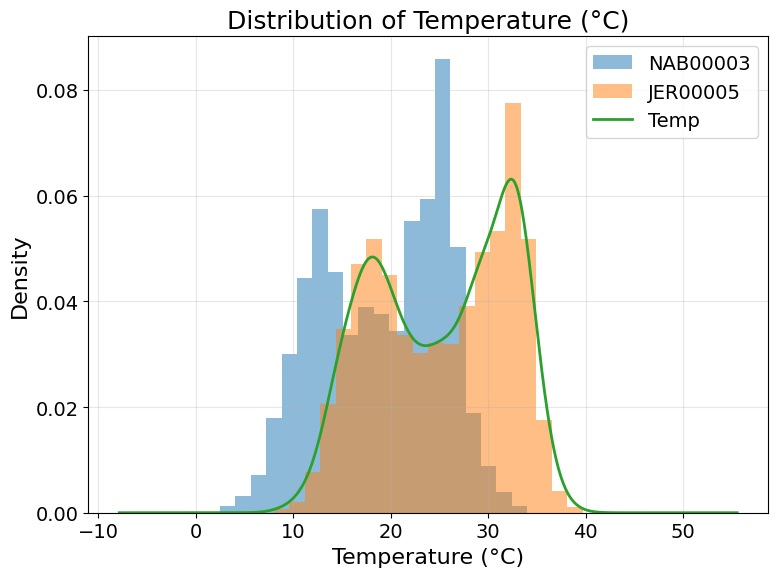

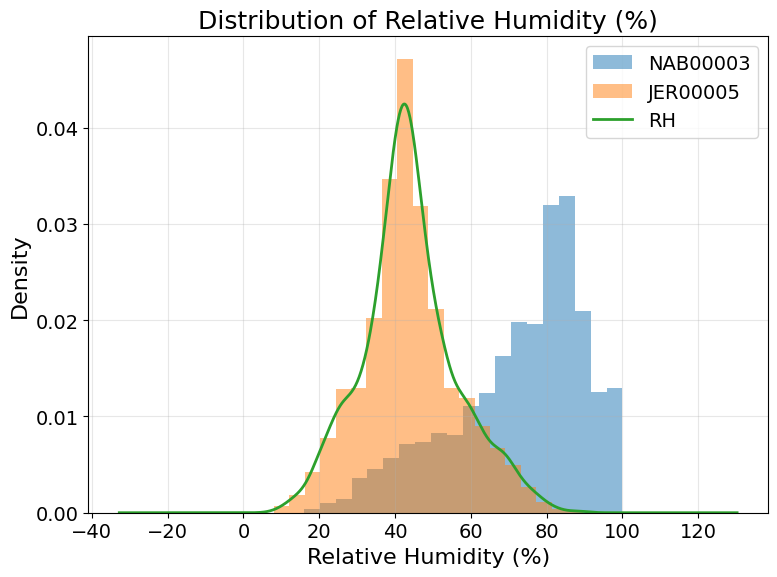

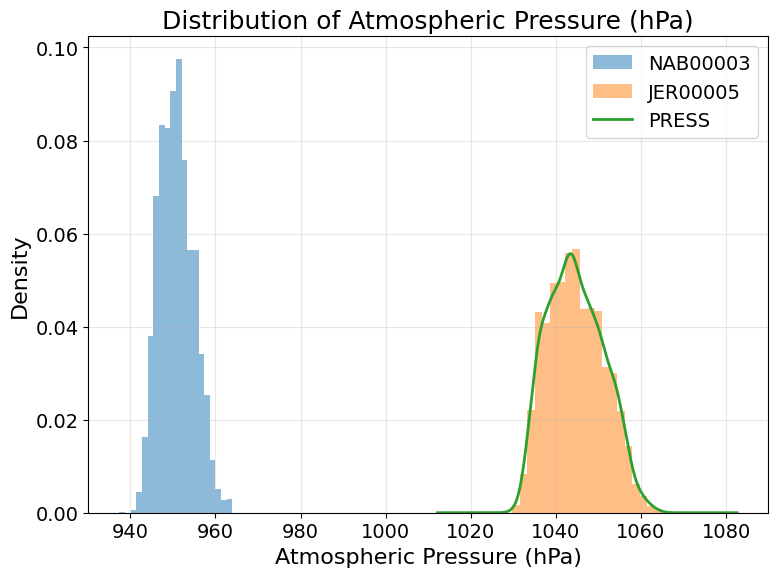

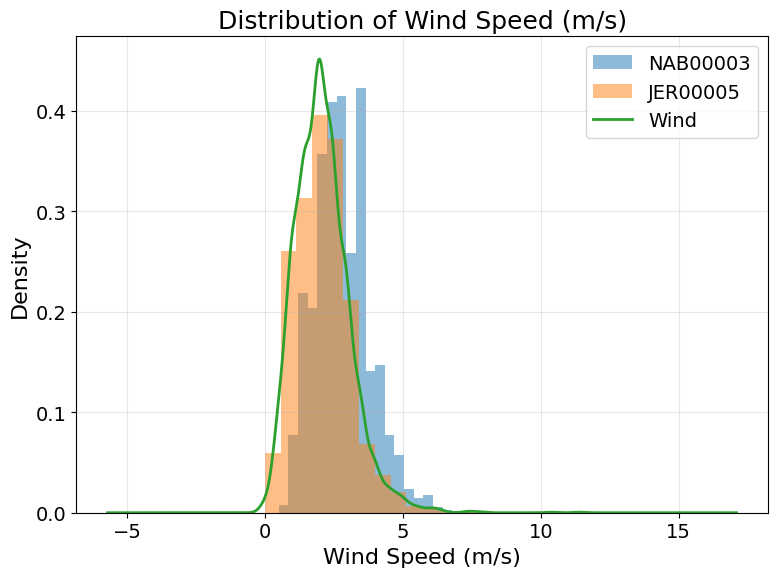

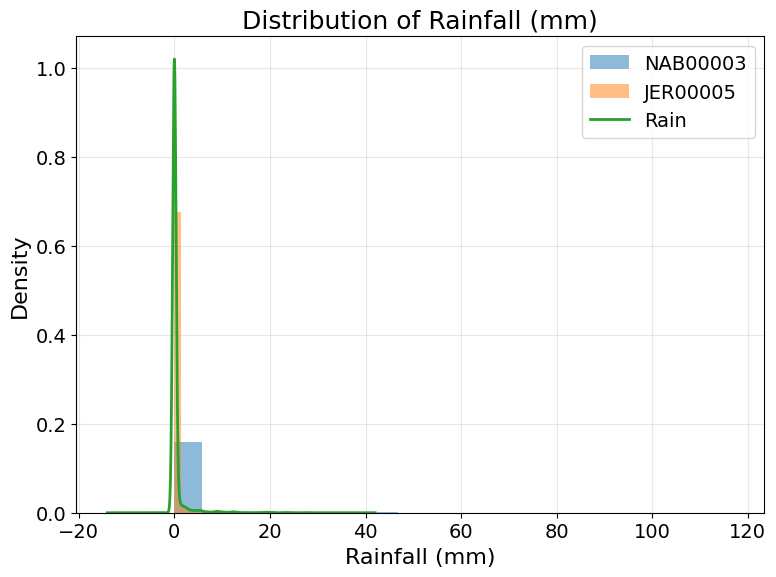

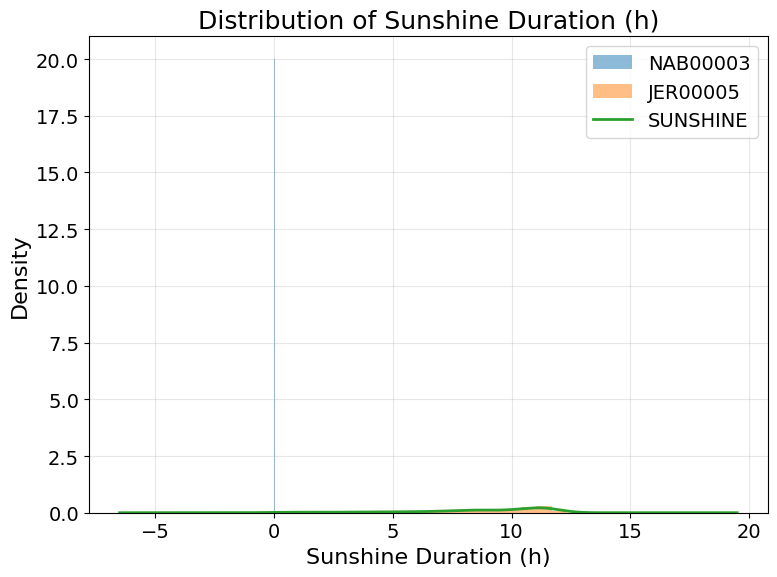

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ===========================
# Load dataset
# ===========================
df = pd.read_excel("/Users/mac/Desktop/enve/final enve/final_filled_climate.xlsx")   # Change path if needed

# ===========================
# Select stations
# ===========================
stations = ["NAB00003", "JER00005"]     # Change if your station names differ
df = df[df["Station"].isin(stations)]

# ===========================
# Variables to plot
# ===========================
variables = [
    "Temp",
    "RH",
    "PRESS",
    "Wind",
    "Rain",
    "SUNSHINE"
]

titles = {
    "Temp":"Temperature (°C)",
    "RH":"Relative Humidity (%)",
    "PRESS":"Atmospheric Pressure (hPa)",
    "Wind":"Wind Speed (m/s)",
    "Rain":"Rainfall (mm)",
    "SUNSHINE":"Sunshine Duration (h)"
}

# ===========================
# Plot settings
# ===========================
plt.rcParams.update({
    "font.size":14,
    "axes.labelsize":16,
    "axes.titlesize":18,
    "legend.fontsize":14
})

# ===========================
# Create figures
# ===========================
for var in variables:

    plt.figure(figsize=(8,6))

    for station in stations:

        data = df[df["Station"]==station][var].dropna()

        plt.hist(
            data,
            bins=20,
            density=True,
            alpha=0.5,
            label=station
        )

    if data.nunique() > 1:
     data.plot(kind="density", linewidth=2)

    plt.xlabel(titles[var])
    plt.ylabel("Density")
    plt.title(f"Distribution of {titles[var]}")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        f"{var}_distribution.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()